Vector v w.r.t the old coordinates: [3 2]
Change-of-basis matrix B w.r.t the old basis:
 [[ 2 -1]
 [ 1  2]]
Vector v w.r.t the new basis: B^-1 w.r.t the old basis @ v w.r.t old basis = [1.6 0.2]
Reconstructed v (should equal [3, 2]): B w.r.t the old basis @ v w.r.t new basis = [3. 2.]
Contribution along b1: [3.2 1.6]
Contribution along b2: [-0.2  0.4]


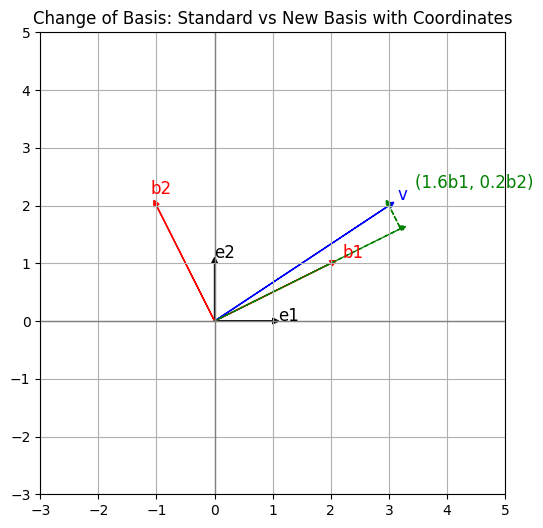

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original old basis vectors
e1 = np.array([1, 0])
e2 = np.array([0, 1])

# Define a vector w.r.t the old coordinates
v_wrt_old = np.array([3, 2])
print("Vector v w.r.t the old coordinates:", v_wrt_old)

# Define new basis vectors
b1_wrt_old = np.array([2, 1])
b2_wrt_old = np.array([-1, 2])
B_wrt_old = np.column_stack((b1_wrt_old, b2_wrt_old))  # Change-of-basis matrix
print("Change-of-basis matrix B w.r.t the old basis:\n", B_wrt_old)

# To find coordinates (a, b) for which v = a*b1 + b*b2,
# solve B * [a, b]^T = v => [a, b]^T = inv(B) * v
v_wrt_new = np.linalg.inv(B_wrt_old).dot(v_wrt_old) # coordinates with respect to new basis
print("Vector v w.r.t the new basis: B^-1 w.r.t the old basis @ v w.r.t old basis =", v_wrt_new)

# For demonstration, reconstruct v using new basis coordinates
v_reconstructed = B_wrt_old.dot(v_wrt_new)
print("Reconstructed v (should equal [3, 2]): B w.r.t the old basis @ v w.r.t new basis =", v_reconstructed)

# Compute the contributions along each new basis vector
comp_b1 = v_wrt_new[0] * b1_wrt_old
comp_b2 = v_wrt_new[1] * b2_wrt_old
print("Contribution along b1:", comp_b1)
print("Contribution along b2:", comp_b2)

plt.figure(figsize=(6, 6))

# Plot the standard basis (black)
plt.arrow(0, 0, e1[0], e1[1], head_width=0.1, head_length=0.1, fc='black', ec='black')
plt.arrow(0, 0, e2[0], e2[1], head_width=0.1, head_length=0.1, fc='black', ec='black')
plt.text(e1[0]*1.1, e1[1]*1.1, 'e1', fontsize=12)
plt.text(e2[0]*1.1, e2[1]*1.1, 'e2', fontsize=12)

# Plot the new basis (red)
plt.arrow(0, 0, b1_wrt_old[0], b1_wrt_old[1], head_width=0.1, head_length=0.1, fc='red', ec='red')
plt.arrow(0, 0, b2_wrt_old[0], b2_wrt_old[1], head_width=0.1, head_length=0.1, fc='red', ec='red')
plt.text(b1_wrt_old[0]*1.1, b1_wrt_old[1]*1.1, 'b1', fontsize=12, color='red')
plt.text(b2_wrt_old[0]*1.1, b2_wrt_old[1]*1.1, 'b2', fontsize=12, color='red')

# Plot vector v (blue)
plt.arrow(0, 0, v_wrt_old[0], v_wrt_old[1], head_width=0.1, head_length=0.1, fc='blue', ec='blue')
plt.text(v_wrt_old[0]*1.05, v_wrt_old[1]*1.05, 'v', fontsize=12, color='blue')

# Plot the new coordinate components as dashed arrows (green)
plt.arrow(x=0, y=0, 
          dx=comp_b1[0], dy=comp_b1[1], head_width=0.1, head_length=0.1, fc='green', ec='green', linestyle='--')
plt.arrow(x=comp_b1[0], y=comp_b1[1], 
          dx=comp_b2[0], dy=comp_b2[1], head_width=0.1, head_length=0.1, fc='green', ec='green', linestyle='--')
plt.text(x=(comp_b1[0]+comp_b2[0])*1.15, y=(comp_b1[1]+comp_b2[1])*1.15,
         s=f'({v_wrt_new[0]:.1f}b1, {v_wrt_new[1]:.1f}b2)', fontsize=12, color='green')
# comp_b1[0]+comp_b2[0] = v[0]
# comp_b1[1]+comp_b2[1] = v[1]

plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.xlim(-3, 5)
plt.ylim(-3, 5)
plt.title("Change of Basis: Standard vs New Basis with Coordinates")
plt.grid(True)
plt.show()